# 다중 실험 결과 비교 시각화

이 노트북은 experiment_date만 입력하면 해당 날짜의 모든 `*_learning.json` 파일들을 자동으로 로드해서 비교 시각화하는 기능을 제공합니다.

In [1]:
import os

os.chdir("/home/youngjins/project/belief_trading/")

import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from typing import Dict
import glob

# 스타일 설정
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")
plt.rcParams["font.size"] = 14
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 12

In [7]:
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

softmax(np.array([8, -8]))

array([9.99999887e-01, 1.12535162e-07])

In [2]:
# 다중 실험 결과 비교를 위한 설정
experiment_date_compare = "20250612_1611"  # 비교하고 싶은 실험 날짜 입력

def load_all_experiments(experiment_date: str) -> Dict[str, Dict]:
    """주어진 실험 날짜의 모든 learning.json 파일들을 로드"""
    results_dir = os.path.join("./results/exp2", experiment_date)
    
    if not os.path.exists(results_dir):
        print(f"실험 디렉토리가 존재하지 않습니다: {results_dir}")
        return {}
    
    # *_learning.json 패턴의 파일들 찾기
    pattern = os.path.join(results_dir, "*_learning.json")
    json_files = glob.glob(pattern)
    
    experiments = {}
    for file_path in json_files:
        # 파일명에서 experiment label 추출 (예: L1B_vs_L2S_learning.json -> L1B_vs_L2S)
        file_name = os.path.basename(file_path)
        label = file_name.replace("_learning.json", "")
        
        try:
            with open(file_path, "r") as f:
                experiments[label] = json.load(f)
            print(f"로드됨: {label}")
        except Exception as e:
            print(f"로드 실패 {label}: {e}")
    
    return experiments

# 모든 실험 결과 로드
all_experiments = load_all_experiments(experiment_date_compare)
all_experiments = dict(sorted(all_experiments.items(), key=lambda x: x[0]))  # 정렬
print(f"\n총 {len(all_experiments)}개의 실험이 로드되었습니다.")
print("실험 목록:", list(all_experiments.keys()))

로드됨: L1B_vs_L1S
로드됨: L3B_vs_L3S
로드됨: L1B_vs_L2S
로드됨: L2B_vs_L2S
로드됨: L0B_vs_L1S
로드됨: L2B_vs_L3S

총 6개의 실험이 로드되었습니다.
실험 목록: ['L0B_vs_L1S', 'L1B_vs_L1S', 'L1B_vs_L2S', 'L2B_vs_L2S', 'L2B_vs_L3S', 'L3B_vs_L3S']


In [3]:
# 다중 실험 결과 기본 정보 비교
def display_experiment_summary(experiments: Dict[str, Dict]):
    """모든 실험의 기본 정보를 테이블 형태로 표시"""
    summary_data = []
    
    for label, results in experiments.items():
        summary_data.append({
            '실험명': label,
            '구매자 레벨': results['buyer_level'],
            '판매자 레벨': results['seller_level'],
            '게임 수': len(results['games']),
            '수렴 여부': results['convergence_info']['converged'],
            '최종 손실': f"{results['convergence_info']['final_loss']:.6f}",
            '최저 손실': f"{results['convergence_info']['best_loss']:.6f}",
            '실행 시간(분)': f"{results['execution_time_seconds']/60:.1f}"
        })
    
    df = pd.DataFrame(summary_data)
    return df

# 실험 요약 표시
if all_experiments:
    summary_df = display_experiment_summary(all_experiments)
    print("실험 결과 요약:")
    print(summary_df.to_string(index=False))
else:
    print("로드된 실험 데이터가 없습니다.")

실험 결과 요약:
       실험명  구매자 레벨  판매자 레벨  게임 수  수렴 여부     최종 손실    최저 손실 실행 시간(분)
L0B_vs_L1S       0       1   995   True  0.047055 0.047055      0.3
L1B_vs_L1S       1       1  1000  False  0.193225 0.153298      0.3
L1B_vs_L2S       1       2  1000  False  0.445750 0.414224      1.0
L2B_vs_L2S       2       2  1000  False 23.025851 3.435706      1.3
L2B_vs_L3S       2       3   546   True  0.046895 0.046895     15.6
L3B_vs_L3S       3       3   576   True  0.044722 0.044722     16.8


/tmp/ipykernel_10054/1264841274.py:66: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax3.set_xticklabels(labels, rotation=45, ha='right')
/tmp/ipykernel_10054/1264841274.py:76: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax4.set_xticklabels(labels, rotation=45, ha='right')


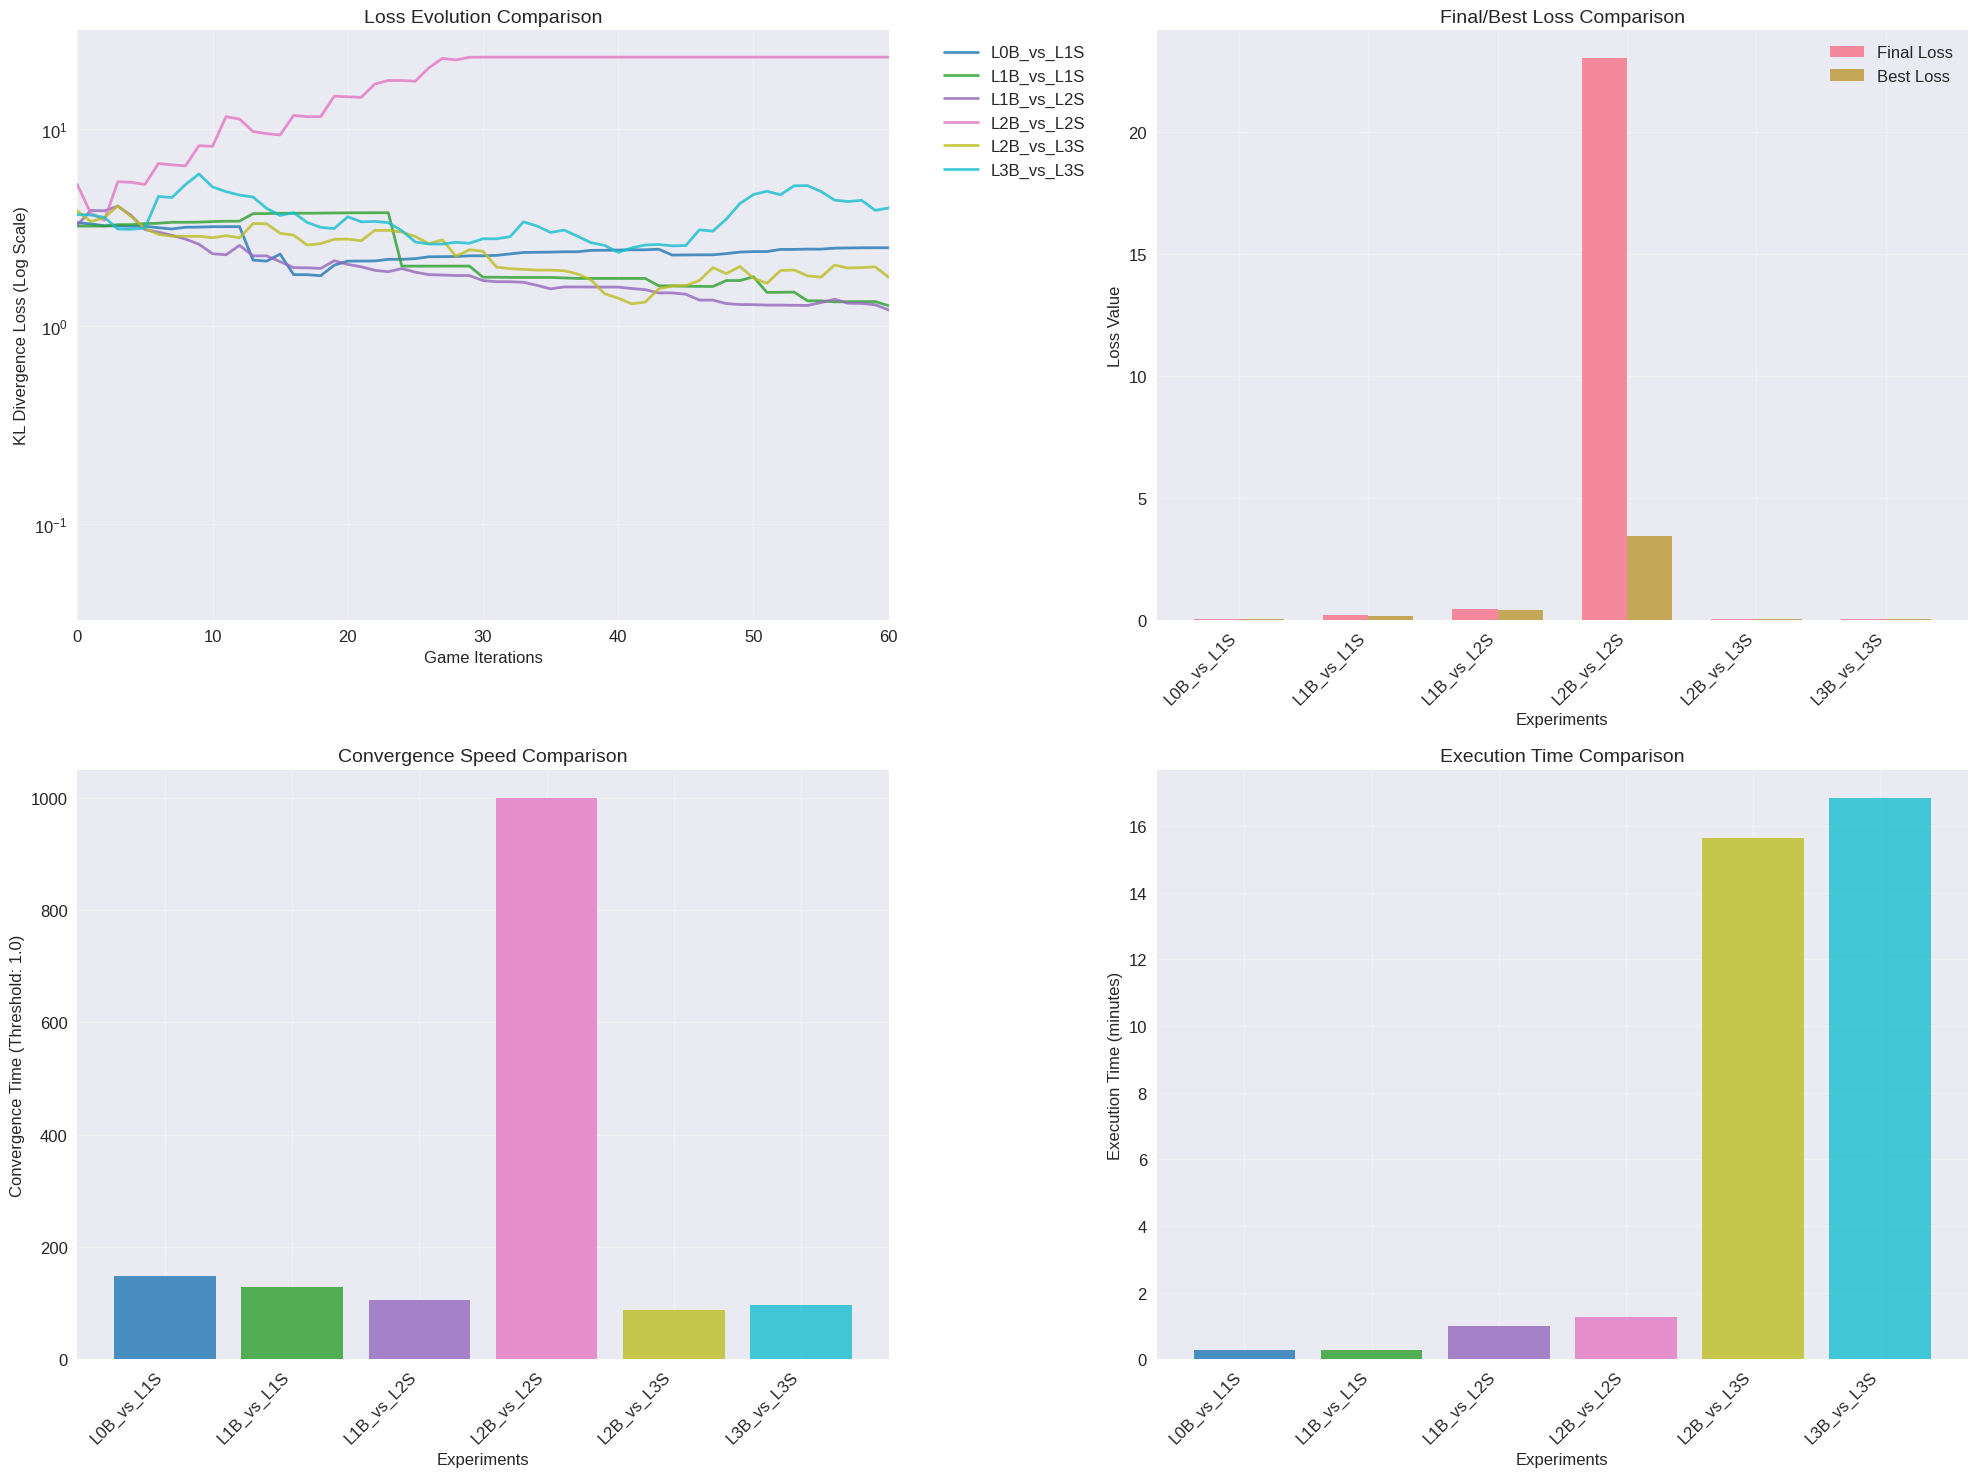

In [4]:
# 다중 실험 Loss 비교 시각화
def plot_multiple_loss_comparison(experiments: Dict[str, Dict]):
    """여러 실험의 Loss 진화 비교"""
    
    # 2x2 서브플롯 생성
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 15))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(experiments)))
    
    # 1. Loss 진화 비교 (로그 스케일)
    for i, (label, results) in enumerate(experiments.items()):
        games = results['games']
        losses = [game['current_loss'] for game in games]
        iterations = list(range(len(losses)))
        
        ax1.plot(iterations, losses, linewidth=2, label=label, color=colors[i], alpha=0.8)
    
    ax1.set_xlabel("Game Iterations")
    ax1.set_ylabel("KL Divergence Loss (Log Scale)")
    ax1.set_title("Loss Evolution Comparison")
    ax1.set_yscale("log")
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.set_xlim(0, 60)
    ax1.grid(True, alpha=0.3)
    
    # 2. 최종 손실 바 차트
    labels = list(experiments.keys())
    final_losses = [exp['convergence_info']['final_loss'] for exp in experiments.values()]
    best_losses = [exp['convergence_info']['best_loss'] for exp in experiments.values()]
    
    x = np.arange(len(labels))
    width = 0.35
    
    ax2.bar(x - width/2, final_losses, width, label='Final Loss', alpha=0.8)
    ax2.bar(x + width/2, best_losses, width, label='Best Loss', alpha=0.8)
    
    ax2.set_xlabel("Experiments")
    ax2.set_ylabel("Loss Value")
    ax2.set_title("Final/Best Loss Comparison")
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels, rotation=45, ha='right')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. 수렴 속도 비교 (손실이 특정 임계값 이하로 떨어지는 시점)
    convergence_times = []
    threshold = 1.0  # 수렴 임계값
    
    for label, results in experiments.items():
        games = results['games']
        losses = [game['current_loss'] for game in games]
        
        # 임계값 이하로 떨어지는 첫 번째 시점 찾기
        conv_time = None
        for i, loss in enumerate(losses):
            if loss < threshold:
                conv_time = i
                break
        
        convergence_times.append(conv_time if conv_time is not None else len(losses))
    
    ax3.bar(labels, convergence_times, alpha=0.8, color=colors)
    ax3.set_xlabel("Experiments")
    ax3.set_ylabel(f"Convergence Time (Threshold: {threshold})")
    ax3.set_title("Convergence Speed Comparison")
    ax3.set_xticklabels(labels, rotation=45, ha='right')
    ax3.grid(True, alpha=0.3)
    
    # 4. 실행 시간 비교
    execution_times = [exp['execution_time_seconds']/60 for exp in experiments.values()]  # 분 단위
    
    ax4.bar(labels, execution_times, alpha=0.8, color=colors)
    ax4.set_xlabel("Experiments")
    ax4.set_ylabel("Execution Time (minutes)")
    ax4.set_title("Execution Time Comparison")
    ax4.set_xticklabels(labels, rotation=45, ha='right')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 다중 실험 Loss 비교 시각화 실행
if all_experiments:
    plot_multiple_loss_comparison(all_experiments)
else:
    print("비교할 실험 데이터가 없습니다.")

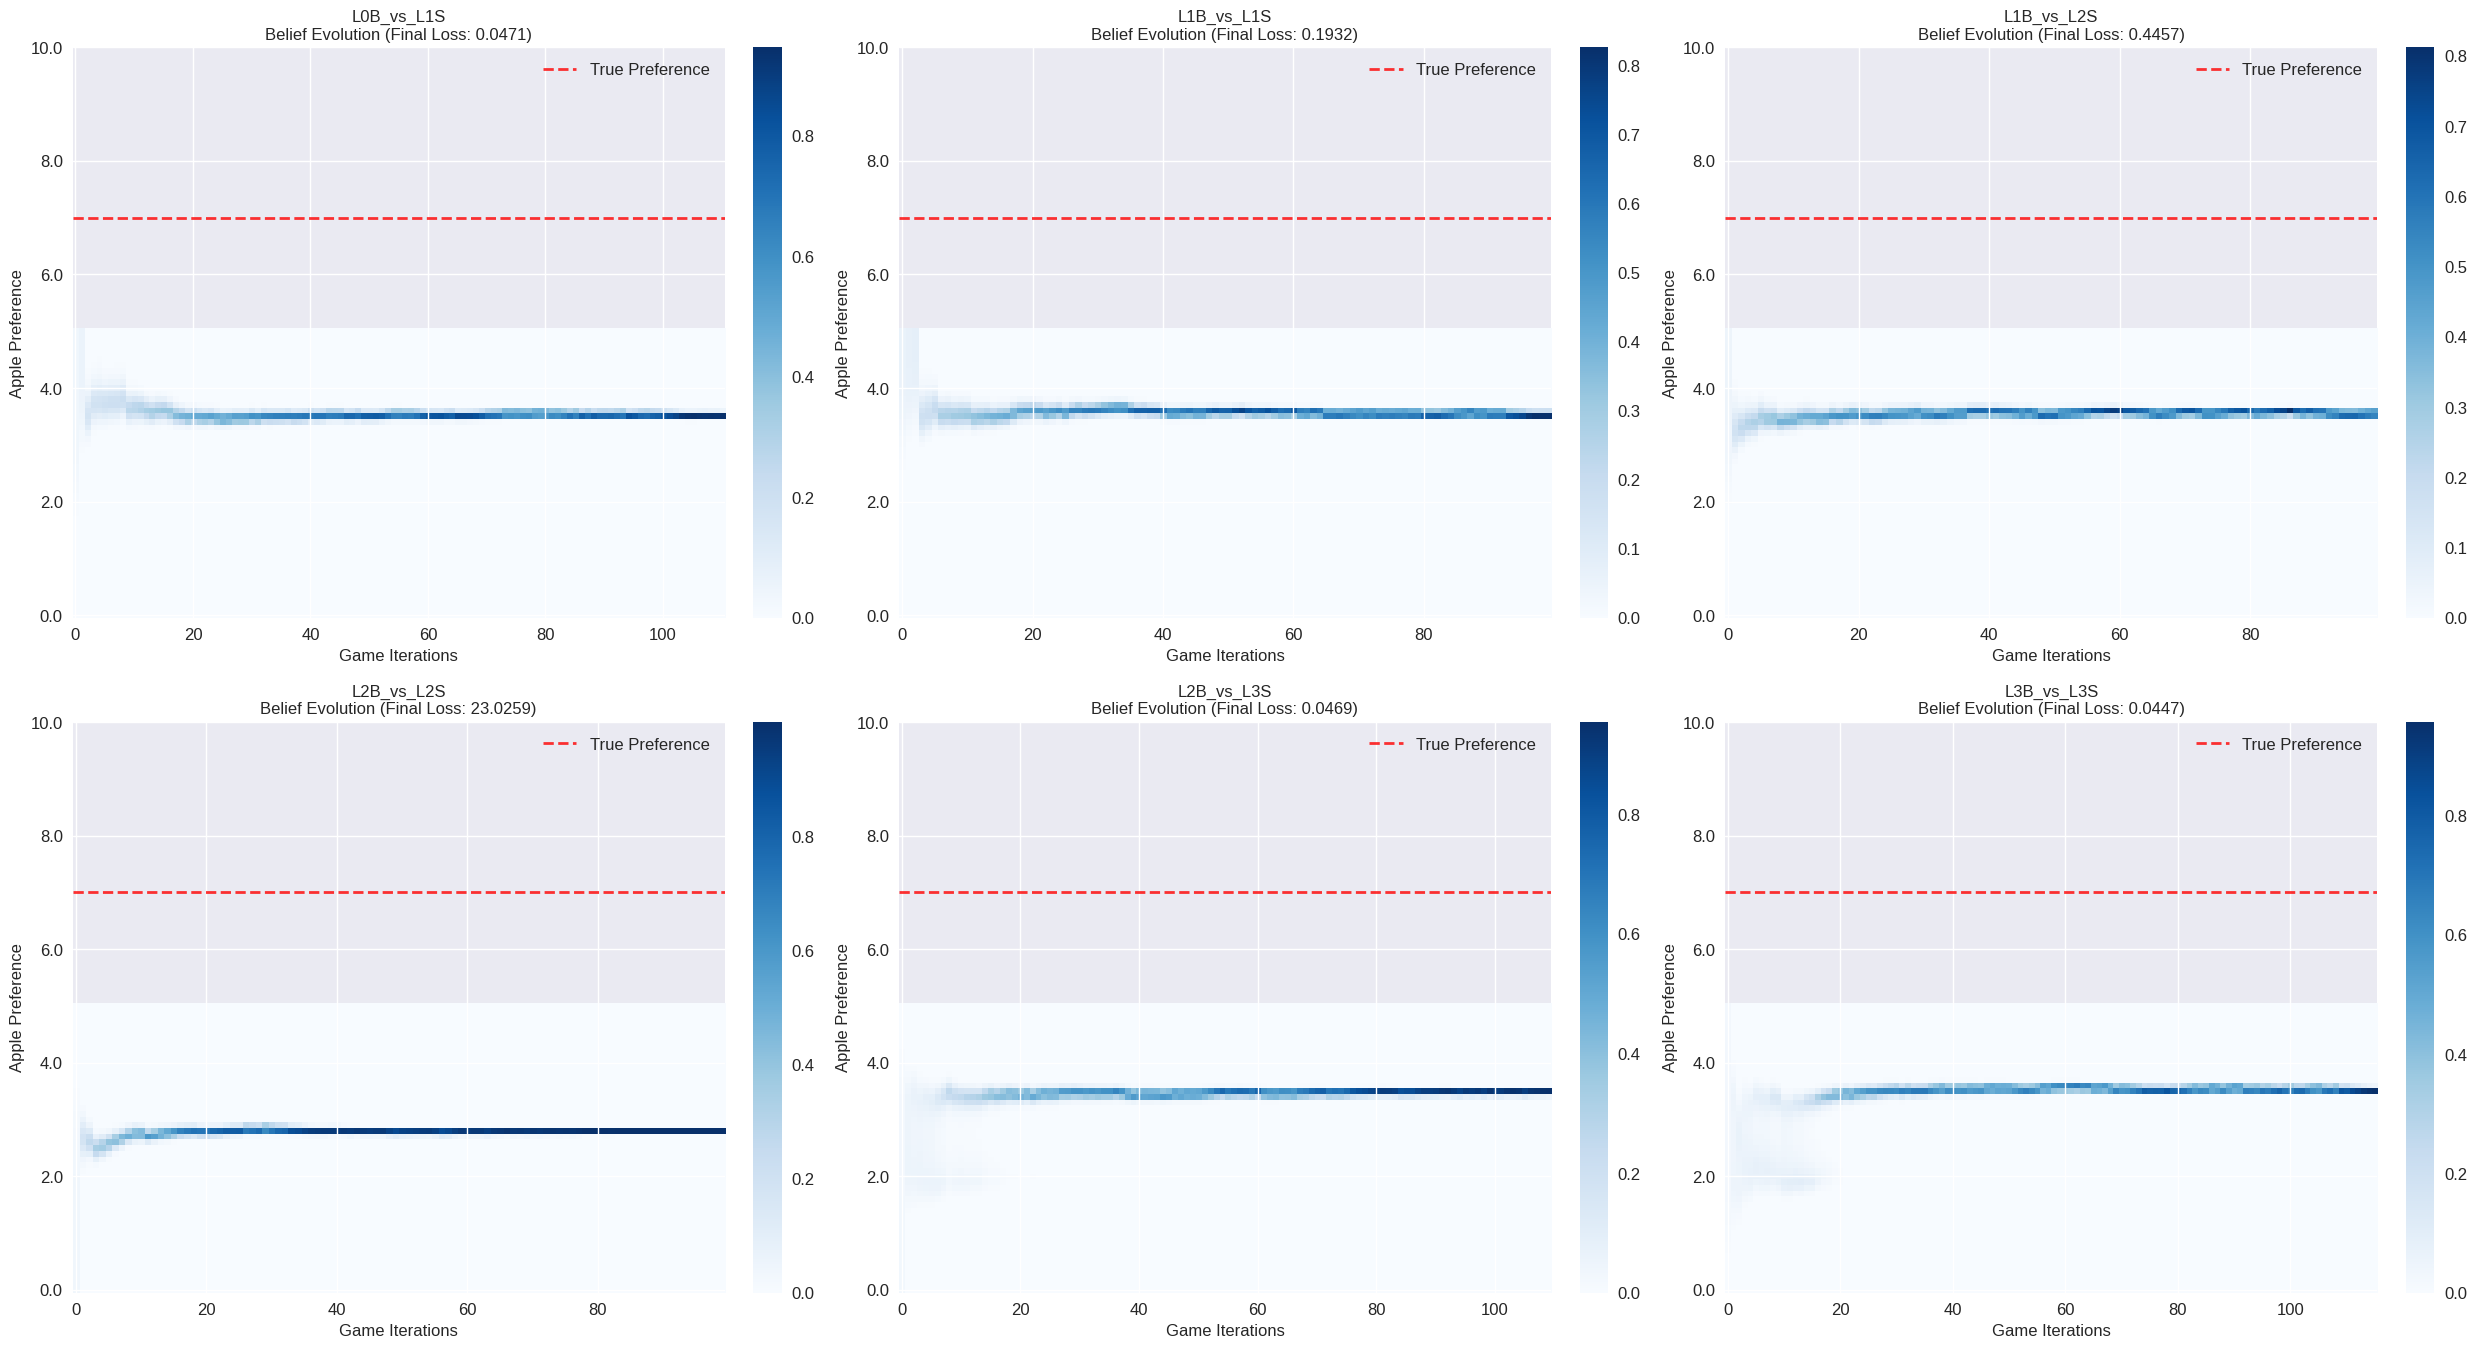

In [5]:
# 다중 실험 믿음 진화 비교
def plot_multiple_belief_evolution(experiments: Dict[str, Dict], sample_points: int = 100):
    """여러 실험의 믿음 진화 과정 비교"""
    
    # 실험 개수에 따라 서브플롯 배치 결정
    n_experiments = len(experiments)
    if n_experiments <= 4:
        fig, axes = plt.subplots(2, 2, figsize=(20, 15))
        axes = axes.ravel()
    else:
        # 더 많은 실험이 있을 경우 3x3 그리드 사용
        fig, axes = plt.subplots(3, 3, figsize=(25, 20))
        axes = axes.ravel()
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(experiments)))
    
    # 각 실험별로 믿음 진화 시각화
    for i, (label, results) in enumerate(experiments.items()):
        if i >= len(axes):
            break
            
        ax = axes[i]
        
        games = results['games']
        beliefs = [game['seller_belief'] for game in games]
        true_preference = results['true_preference']
        preference_grid = np.linspace(0, 10, 101)
        
        # 샘플링하여 시각화 (너무 많은 데이터 포인트 방지)
        if len(beliefs) > sample_points:
            step = len(beliefs) // sample_points
            sampled_beliefs = beliefs[::step]
            sampled_iterations = list(range(0, len(beliefs), step))
        else:
            sampled_beliefs = beliefs
            sampled_iterations = list(range(len(beliefs)))
        
        # 믿음 진화를 히트맵으로 표시
        if sampled_beliefs:
            belief_matrix = np.array(sampled_beliefs).T
            im = ax.imshow(belief_matrix, aspect='auto', origin='lower', cmap='Blues')
            
            # True preference 라인 표시
            true_apple_pref = true_preference[0]
            true_idx = np.argmin(np.abs(np.array(preference_grid) - true_apple_pref))
            ax.axhline(y=true_idx, color='red', linestyle='--', linewidth=2, alpha=0.8, label='True Preference')
            
            ax.set_title(f'{label}\nBelief Evolution (Final Loss: {results["convergence_info"]["final_loss"]:.4f})', fontsize=12)
            ax.set_xlabel('Game Iterations')
            ax.set_ylabel('Apple Preference')
            
            # Y축 눈금 설정
            y_ticks = np.arange(0, len(preference_grid), 20)
            ax.set_yticks(y_ticks)
            ax.set_yticklabels([f"{preference_grid[i]:.1f}" for i in y_ticks])
            
            ax.legend()
            
            # 컬러바 추가
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    # 사용하지 않는 서브플롯 숨기기
    for j in range(len(experiments), len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# 다중 실험 믿음 진화 비교 실행
if all_experiments:
    plot_multiple_belief_evolution(all_experiments)
else:
    print("비교할 실험 데이터가 없습니다.")

ValueError: x and y must have same first dimension, but have shapes (101,) and (51,)

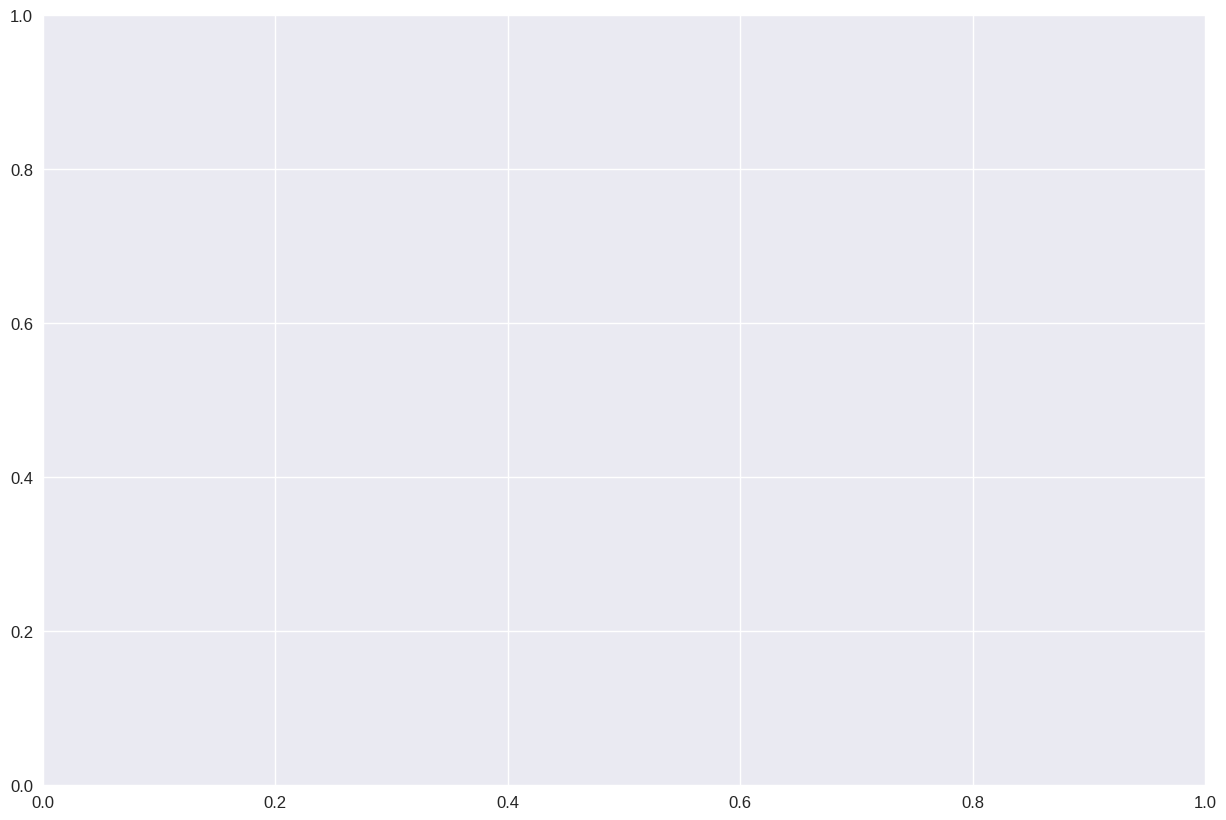

In [6]:
# Final belief distribution comparison
def plot_final_belief_comparison(experiments: Dict[str, Dict]):
    """Compare final belief distributions across multiple experiments"""
    plt.figure(figsize=(15, 10))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(experiments)))
    
    for i, (label, results) in enumerate(experiments.items()):
        games = results['games']
        final_belief = games[-1]['seller_belief']
        preference_grid = np.linspace(0, 10, 101)
        true_preference = results['true_preference']
        
        plt.plot(preference_grid, final_belief, linewidth=2.5, 
                label=f'{label} (Final Loss: {results["convergence_info"]["final_loss"]:.4f})', 
                color=colors[i], alpha=0.8)
    
    # Display true preference (assuming same across all experiments)
    if experiments:
        true_apple_pref = list(experiments.values())[0]['true_preference'][0]
        plt.axvline(x=true_apple_pref, color='red', linestyle='--', linewidth=3, 
                   alpha=0.8, label=f'True Apple Preference: {true_apple_pref}')
    
    plt.xlabel('Apple Preference', fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.title('Final Belief Distribution Comparison', fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Execute final belief distribution comparison
if all_experiments:
    plot_final_belief_comparison(all_experiments)
else:
    print("비교할 실험 데이터가 없습니다.")

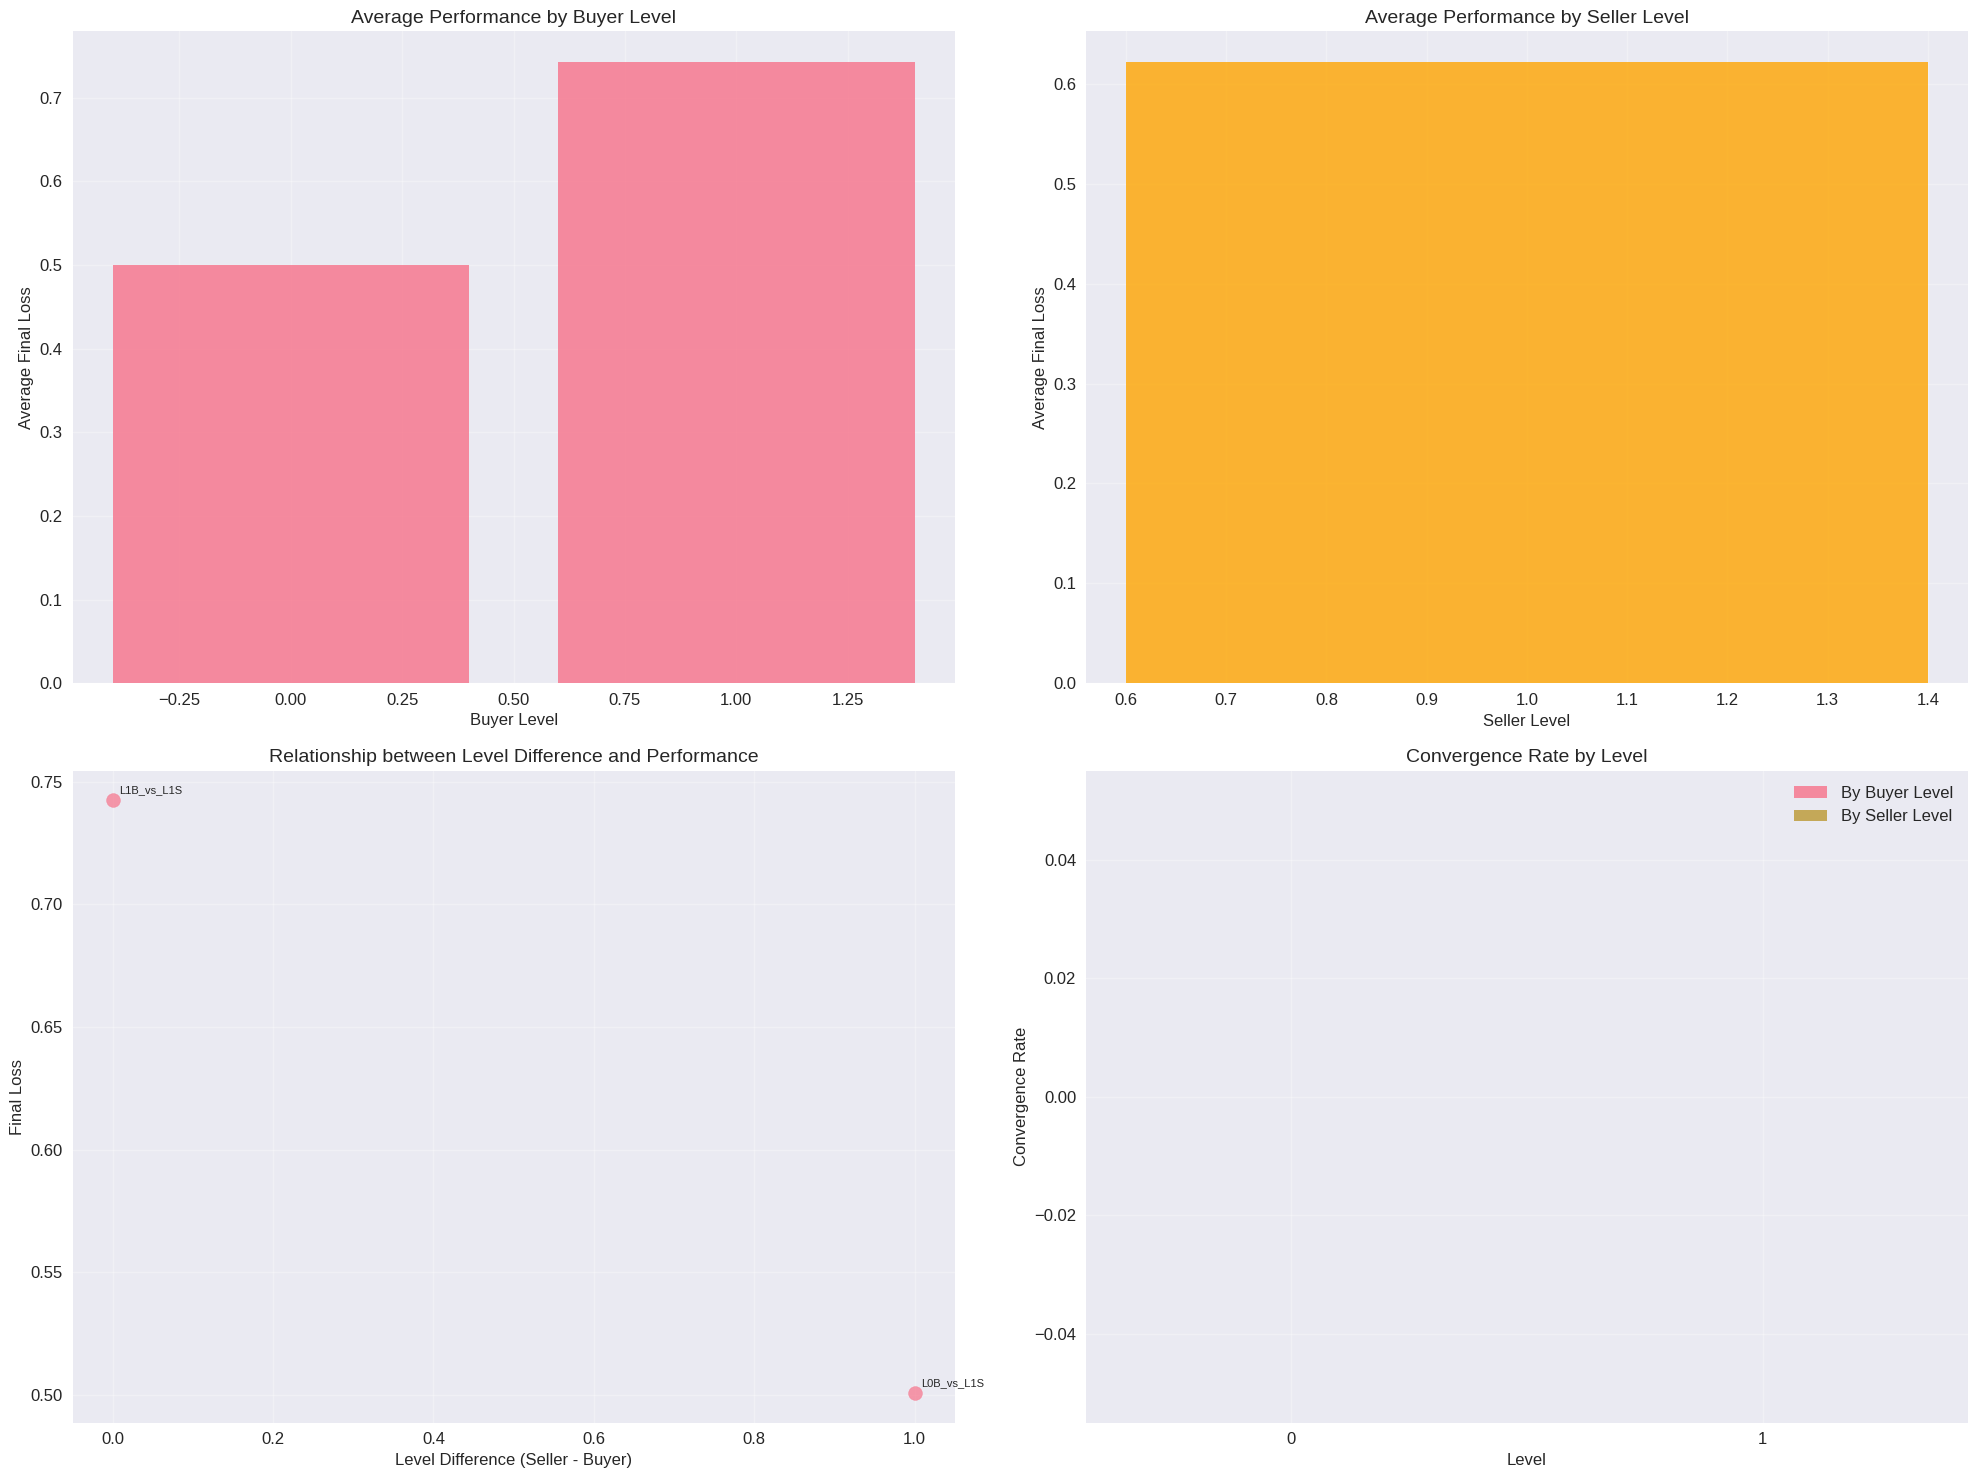


Level-wise performance analysis completed
Detailed data:
  experiment_name  buyer_level  seller_level  final_loss  best_loss  \
0      L0B_vs_L1S            0             1      0.5007     0.4894   
1      L1B_vs_L1S            1             1      0.7424     0.6092   

   converged  execution_time  level_difference  
0      False         92.5707                 1  
1      False         89.3522                 0  


In [7]:
# Level-wise performance analysis
def analyze_performance_by_levels(experiments: Dict[str, Dict]):
    """Performance analysis by buyer/seller levels"""
    # Organize data by levels
    level_data = []
    for label, results in experiments.items():
        level_data.append({
            'experiment_name': label,
            'buyer_level': results['buyer_level'],
            'seller_level': results['seller_level'],
            'final_loss': results['convergence_info']['final_loss'],
            'best_loss': results['convergence_info']['best_loss'],
            'converged': results['convergence_info']['converged'],
            'execution_time': results['execution_time_seconds']
        })
    
    df = pd.DataFrame(level_data)
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 15))
    
    # 1. Performance by buyer level
    buyer_performance = df.groupby('buyer_level')['final_loss'].mean()
    ax1.bar(buyer_performance.index, buyer_performance.values, alpha=0.8)
    ax1.set_xlabel('Buyer Level')
    ax1.set_ylabel('Average Final Loss')
    ax1.set_title('Average Performance by Buyer Level')
    ax1.grid(True, alpha=0.3)
    
    # 2. Performance by seller level
    seller_performance = df.groupby('seller_level')['final_loss'].mean()
    ax2.bar(seller_performance.index, seller_performance.values, alpha=0.8, color='orange')
    ax2.set_xlabel('Seller Level')
    ax2.set_ylabel('Average Final Loss')
    ax2.set_title('Average Performance by Seller Level')
    ax2.grid(True, alpha=0.3)
    
    # 3. Relationship between level difference and performance
    df['level_difference'] = df['seller_level'] - df['buyer_level']
    ax3.scatter(df['level_difference'], df['final_loss'], alpha=0.7, s=100)
    for i, row in df.iterrows():
        ax3.annotate(row['experiment_name'], (row['level_difference'], row['final_loss']), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    ax3.set_xlabel('Level Difference (Seller - Buyer)')
    ax3.set_ylabel('Final Loss')
    ax3.set_title('Relationship between Level Difference and Performance')
    ax3.grid(True, alpha=0.3)
    
    # 4. Convergence rate analysis
    convergence_by_buyer = df.groupby('buyer_level')['converged'].mean()
    convergence_by_seller = df.groupby('seller_level')['converged'].mean()
    
    x = np.arange(len(convergence_by_buyer))
    width = 0.35
    
    ax4.bar(x - width/2, convergence_by_buyer.values, width, label='By Buyer Level', alpha=0.8)
    ax4.bar(x + width/2, convergence_by_seller.values, width, label='By Seller Level', alpha=0.8)
    
    ax4.set_xlabel('Level')
    ax4.set_ylabel('Convergence Rate')
    ax4.set_title('Convergence Rate by Level')
    ax4.set_xticks(x)
    ax4.set_xticklabels(convergence_by_buyer.index)
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return df

# Execute level-wise performance analysis
if all_experiments:
    performance_df = analyze_performance_by_levels(all_experiments)
    print("\nLevel-wise performance analysis completed")
    print("Detailed data:")
    print(performance_df.round(4))
else:
    print("No experimental data available for analysis.")

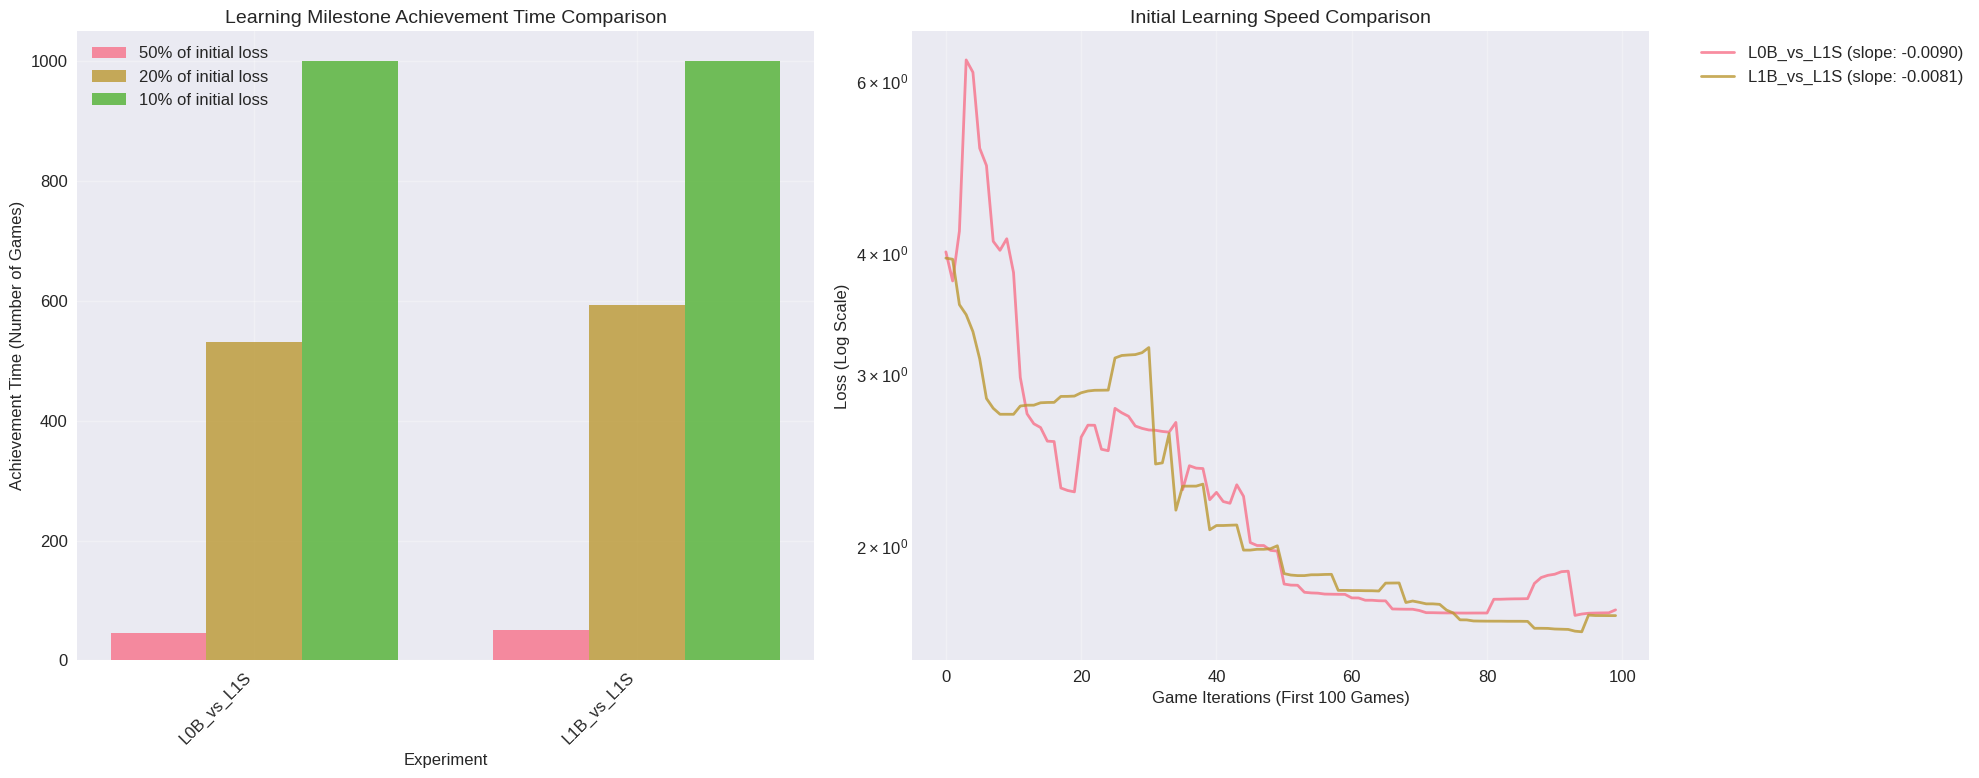

In [ ]:
# Additional analysis: Learning speed comparison
def plot_learning_speed_comparison(experiments: Dict[str, Dict]):
    """Learning speed comparison (time to reach 50%, 20%, 10% of initial loss)"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    milestones = [0.5, 0.2, 0.1]  # 50%, 20%, 10% of initial loss
    milestone_names = ['50%', '20%', '10%']
    
    milestone_data = {name: [] for name in milestone_names}
    labels = []
    
    for label, results in experiments.items():
        games = results['games']
        losses = [game['current_loss'] for game in games]
        
        if len(losses) > 0:
            initial_loss = losses[0]
            labels.append(label)
            
            for i, milestone in enumerate(milestones):
                target_loss = initial_loss * milestone
                milestone_time = None
                
                for j, loss in enumerate(losses):
                    if loss <= target_loss:
                        milestone_time = j
                        break
                
                milestone_data[milestone_names[i]].append(
                    milestone_time if milestone_time is not None else len(losses)
                )
    
    # Milestone achievement time comparison
    x = np.arange(len(labels))
    width = 0.25
    
    for i, (name, times) in enumerate(milestone_data.items()):
        ax1.bar(x + i * width, times, width, label=f'{name} of initial loss', alpha=0.8)
    
    ax1.set_xlabel('Experiment')
    ax1.set_ylabel('Achievement Time (Number of Games)')
    ax1.set_title('Learning Milestone Achievement Time Comparison')
    ax1.set_xticks(x + width)
    ax1.set_xticklabels(labels, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Loss reduction rate comparison (first 100 games)
    for label, results in experiments.items():
        games = results['games']
        losses = [game['current_loss'] for game in games[:min(100, len(games))]]
        
        if len(losses) > 1:
            # Calculate loss reduction rate (slope in log scale)
            x_vals = np.arange(len(losses))
            log_losses = np.log(losses)
            
            # Calculate slope using linear regression
            slope = np.polyfit(x_vals, log_losses, 1)[0]
            
            ax2.plot(x_vals, losses, label=f'{label} (slope: {slope:.4f})', linewidth=2, alpha=0.8)
    
    ax2.set_xlabel('Game Iterations (First 100 Games)')
    ax2.set_ylabel('Loss (Log Scale)')
    ax2.set_title('Initial Learning Speed Comparison')
    ax2.set_yscale('log')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Execute learning speed comparison
if all_experiments:
    plot_learning_speed_comparison(all_experiments)
else:
    print("No experimental data available for comparison.")